In [6]:
from prefect_s3_utils import connect_s3, upload_s3, download_s3
from prefect import flow, task
import pandas as pd


@task(name="Download prior tagged Bills")
def get_tagged_bills() -> pd.DataFrame:
    """
    Downloads previously tagged bills from S3.

    Purpose: Avoids re-processing tags for bills that have already been handled.

    Returns:
        pd.DataFrame: A DataFrame containing previously tagged bills,
                      including a 'dataset_hash' column used for deduplication.
    """
    s3 = connect_s3('portfolio-project-files')

    tagged_bills = download_s3(s3, 'sdg-bill-tracking/tagged_bills.csv')

    corpus = download_s3(s3, 'sdg-bill-tracking/sdg_theme_corpus.csv')    
    return tagged_bills, corpus


@task(name="Upload new tagged bills to S3")
def upload_tagged_bills(tagged_bills_updated: pd.DataFrame) -> None:
    """
    Uploads the updated tagged bills DataFrame to S3.

    Args:
        tagged_bills_updated (pd.DataFrame): The updated DataFrame containing
                                             both old and newly tagged bills.
    """
    s3 = connect_s3('portfolio-project-files')
    upload_s3(s3, 'sdg-bill-tracking/tagged_bills.csv', tagged_bills_updated)


@flow(name='Inspection', log_prints=True)
async def bill_processing_main() -> None:


    tagged_bills, corpus = get_tagged_bills()


    return tagged_bills, corpus



tagged_bills, corpus = await bill_processing_main()

12:49:49.305 | INFO    | prefect.engine - View at https://app.prefect.cloud/account/3f9bd1dc-a34b-4ba7-a6e0-e2aa163f25d6/workspace/4fe3e874-7162-4c73-879d-d1f78dbe5925/runs/flow-run/06a760ca-d340-7f64-8000-db7ad507eb88

12:49:49.495 | INFO    | Flow run 'adorable-piculet' - Beginning flow run 'adorable-piculet' for flow 'Inspection'

12:49:49.497 | INFO    | Flow run 'adorable-piculet' - View at https://app.prefect.cloud/account/3f9bd1dc-a34b-4ba7-a6e0-e2aa163f25d6/workspace/4fe3e874-7162-4c73-879d-d1f78dbe5925/runs/flow-run/06a760ca-d340-7f64-8000-db7ad507eb88

12:50:00.523 | INFO    | Task run 'Download prior tagged Bills-437' - Finished in state Completed()

12:50:00.707 | INFO    | Flow run 'adorable-piculet' - Finished in state Completed()

0.5423251323522589


<Axes: >

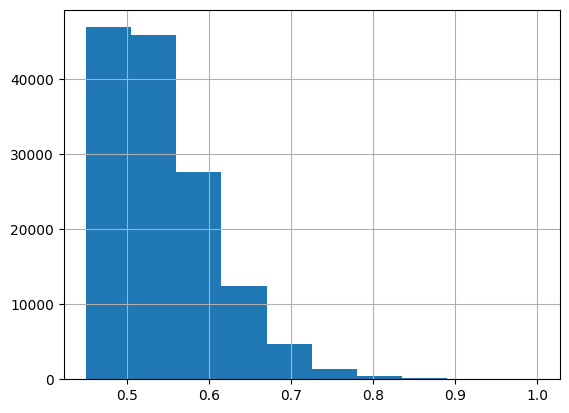

In [57]:
"""
Confidence review
"""
print(tagged_bills.sdg_confidence.mean())
tagged_bills.sdg_confidence.hist()

In [66]:
"""
Percent of bills with match (overall and by jurisdiction)
"""
print( 1 - len(tagged_bills[pd.isna(tagged_bills.sdg_confidence)]) / len(tagged_bills))


tagged_bills.groupby('legislative_body').apply(lambda x: 1 - len(x[pd.isna(x.sdg_confidence)]) / len(x)).reset_index(
    name='percent_with_match').sort_values(by = 'percent_with_match', ascending = False).merge(tagged_bills.groupby('legislative_body').bill_number.nunique().reset_index(name='num_bills'))

0.6724431722187092


/var/folders/vp/6mp4pm_x5b9dv9x975tv3j6m0000gp/T/ipykernel_7840/1287022069.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tagged_bills.groupby('legislative_body').apply(lambda x: 1 - len(x[pd.isna(x.sdg_confidence)]) / len(x)).reset_index(


,legislative_body,percent_with_match,num_bills
0,WV,0.931696,2972
1,WY,0.861446,332
2,US,0.850723,18047
3,ID,0.837209,817
4,IA,0.831203,4224
5,CT,0.828527,1283
6,MA,0.822773,8870
7,FL,0.819077,1898
8,WI,0.811341,2749
9,MD,0.806294,2669


In [73]:
i = 4

temp = tagged_bills[tagged_bills.sdg_number == i]
print(i, temp.sdg_title.values[0])
print()

temp = temp[['title', 'description', 'sdg_tagged_text', 'sdg_theme', 'sdg_confidence']].sample(5).sort_values(by = 'sdg_confidence', ascending = False)

for _, row in temp.iterrows():
    print(row['title'].upper())
    print(row['description'].upper())
    print('\tTheme: ', row['sdg_theme'])
    print('\tTagged text: ', row['sdg_tagged_text'])
    print('\tConfidence: ', row['sdg_confidence'])
    print()

4 Quality Education

STOP CHILD HUNGER ACT OF 2025
TO AMEND THE RICHARD B. RUSSELL NATIONAL SCHOOL LUNCH ACT TO EXPAND THE SUMMER ELECTRONIC BENEFITS TRANSFER FOR CHILDREN PROGRAM TO INCLUDE BENEFIT TRANSFER DURING SCHOOL CLOSURES, AND FOR OTHER PURPOSES.
	Theme:  School Choice & Vouchers
	Tagged text:  To amend eligibility criteria for school voucher programs.
	Confidence:  0.6091851592063904

CREATES A TAX CREDIT FOR EMPLOYERS WHO CONTRIBUTE TO A COLLEGE CHOICE TUITION SAVINGS ACCOUNT ON BEHALF OF AN EMPLOYEE.
CREATES A TAX CREDIT FOR EMPLOYERS WHO CONTRIBUTE TO A COLLEGE CHOICE TUITION SAVINGS ACCOUNT ON BEHALF OF AN EMPLOYEE.
	Theme:  Vocational & Technical Training
	Tagged text:  To establish tax credits for employers providing on-the-job training.
	Confidence:  0.596187174320221

ESTABLISHES A SCHOOL AIR CONDITIONING SYSTEM GRANT PROGRAM TO PROVIDE SCHOOLS WITH FUNDING TO INSTALL AIR CONDITIONING SYSTEMS IN CERTAIN AREAS; MAKES AN APPROPRIATION THEREFOR.
ESTABLISHES A SCHOOL AIR 